<a href="https://colab.research.google.com/github/mans70q/NN/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Controllable Medical Image Synthesis for Skin Cancer Data Augmentation
**Course:** Neural Networks  
**Objective:** Using Stable Diffusion & ControlNet (Canny Edge) to generate synthetic Melanoma images based on structural boundaries of benign skin lesions (ISIC 2019 Dataset) to address class imbalance.



In [ ]:
# Install required libraries
!pip install -q diffusers transformers accelerate opencv-python controlnet_aux kaggle

import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

CUDA Available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 📂 Dataset Preparation (ISIC 2019)
Downloading the dataset directly using the Kaggle API.
*(Note: You will be prompted to upload your `kaggle.json` file).*

In [ ]:
from google.colab import files
import os

print("Please upload your kaggle.json file:")
files.upload()

# Setup Kaggle API and download dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading ISIC 2019 dataset...")
!kaggle datasets download -d andrewmvd/isic-2019 -p /content/isic2019
!unzip -q /content/isic2019/isic-2019.zip -d /content/isic2019
print("✅ Dataset Downloaded and Extracted!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [07:56<00:00, 20.5MB/s]

✅ Dataset Downloaded and Extracted!


### 🖼️ Custom Dataset Class
Defining a PyTorch-style Dataset class to load and handle the ISIC skin images efficiently.

In [ ]:
from PIL import Image
import os

image_dir = "/content/isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

# Get all jpg images
image_paths = [
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.endswith(".jpg")
]

class SkinDataset:
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return {"image": Image.open(self.paths[idx])}

dataset = SkinDataset(image_paths)
print(f"✅ Dataset Initialized! Total size: {len(dataset)} images")

✅ Dataset Initialized! Total size: 25331 images


### 🧠 Model Initialization
Loading the **Stable Diffusion v1.5** pipeline along with **ControlNet (Canny)**. CPU offloading is enabled to optimize VRAM usage on Colab.

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
import torch

print("Initializing models...")

# Load ControlNet
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

# Load Stable Diffusion
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

# Optimizations
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing() # Added to prevent memory errors

print("✅ Pipeline ready!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Initializing models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object in

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object

✅ Pipeline ready!


### 🔬 Proof of Concept: Single Image Inference
Extracting structural boundaries using Canny Edge detection and generating a synthetic Melanoma image.

Generating synthetic image...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

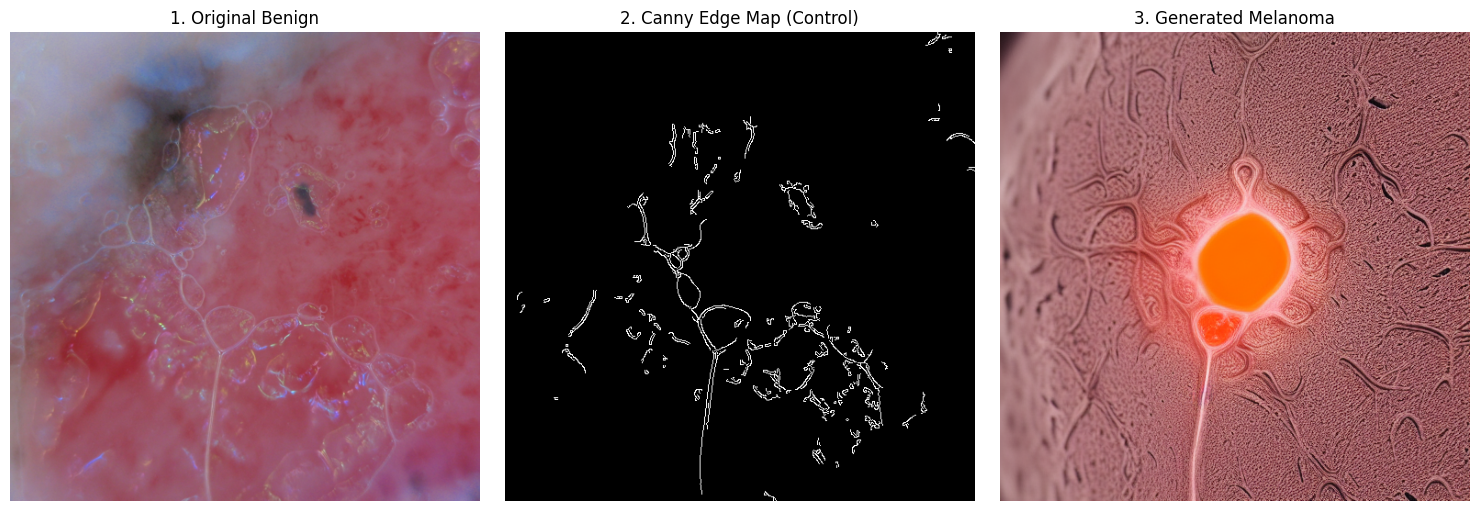

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_canny(image: Image.Image) -> Image.Image:
    """Extracts edges to guide the generation process."""
    img_array = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(edges_rgb)

# 1. Prepare inputs (resize is strictly required for SD)
sample_image = dataset[0]['image'].resize((512, 512))
canny_map = extract_canny(sample_image)

# 2. Medical Prompt
prompt = "high quality dermoscopy image of melanoma skin cancer, irregular borders, clinical photography, medical grade, anatomically accurate, detailed skin texture"

print("Generating synthetic image...")
result = pipe(
    prompt=prompt,
    image=canny_map,
    num_inference_steps=30,
    guidance_scale=7.5,
    controlnet_conditioning_scale=0.8
).images[0]

# 3. Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_image); axes[0].set_title("1. Original Benign")
axes[1].imshow(canny_map);    axes[1].set_title("2. Canny Edge Map (Control)")
axes[2].imshow(result);       axes[2].set_title("3. Generated Melanoma")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 🔄 Data Augmentation Pipeline
Simulating the actual data augmentation process by generating a mini-batch of synthetic medical images.

In [ ]:
import os

output_folder = "/content/synthetic_melanoma_dataset"
os.makedirs(output_folder, exist_ok=True)

print("🚀 Starting Data Augmentation...")

# Generate 3 variations from the same structural map
num_images = 3

for i in range(num_images):
    print(f"⏳ Generating synthetic image {i+1}/{num_images}...")

    # Generate
    synthetic_img = pipe(
        prompt=prompt,
        image=canny_map,
        num_inference_steps=30,
        guidance_scale=7.5 + (i * 0.5), # Slight variation in guidance for diversity
        controlnet_conditioning_scale=0.8
    ).images[0]

    # Save
    save_path = os.path.join(output_folder, f"synthetic_melanoma_aug_{i+1}.jpg")
    synthetic_img.save(save_path)

print(f"✅ Data Augmentation Complete! Images saved in: {output_folder}")

🚀 Starting Data Augmentation...
⏳ Generating synthetic image 1/3...


/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

⏳ Generating synthetic image 2/3...


...

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

⏳ Generating synthetic image 3/3...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

✅ Data Augmentation Complete! Images saved in: /content/synthetic_melanoma_dataset


🚀 Starting Data Augmentation...
⏳ Generating synthetic image 1/3...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

⏳ Generating synthetic image 2/3...


  0%|          | 0/30 [00:00<?, ?it/s]

...

⏳ Generating synthetic image 3/3...


/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprec

✅ Data Augmentation Complete! Displaying results...


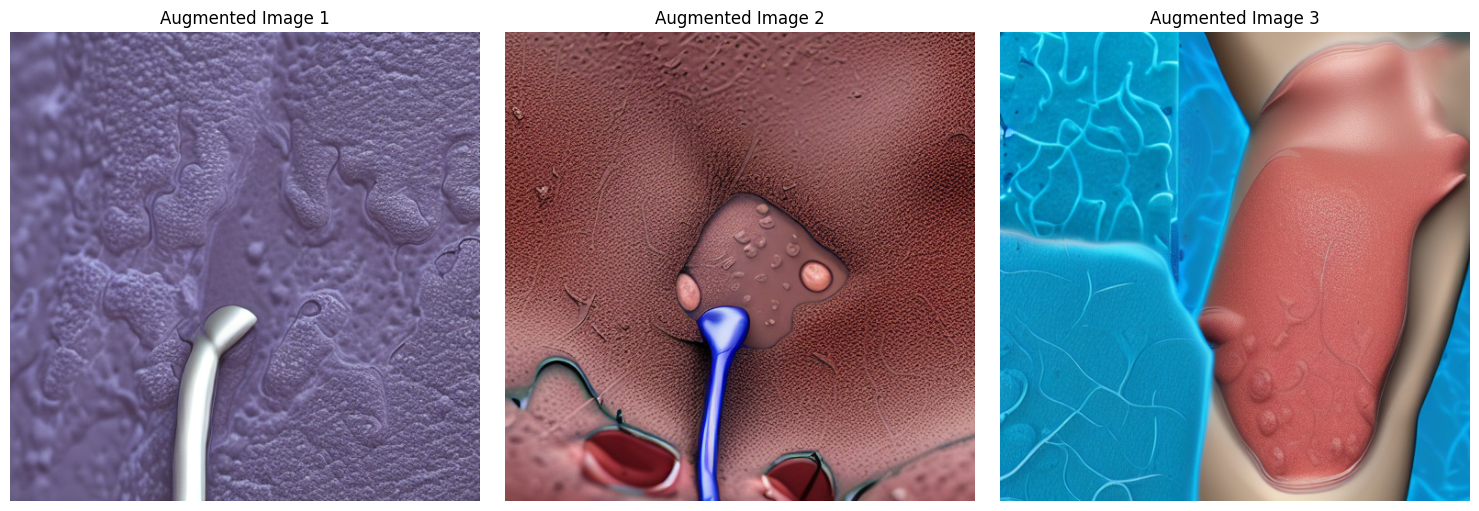

In [ ]:
import os
import matplotlib.pyplot as plt

output_folder = "/content/synthetic_melanoma_dataset"
os.makedirs(output_folder, exist_ok=True)

print("🚀 Starting Data Augmentation...")
num_images = 3
generated_images = [] # قائمة لتخزين الصور لعرضها لاحقاً

for i in range(num_images):
    print(f"⏳ Generating synthetic image {i+1}/{num_images}...")

    # Generate
    synthetic_img = pipe(
        prompt=prompt,
        image=canny_map,
        num_inference_steps=30,
        guidance_scale=7.5 + (i * 0.5),
        controlnet_conditioning_scale=0.8
    ).images[0]

    # Save
    save_path = os.path.join(output_folder, f"synthetic_melanoma_aug_{i+1}.jpg")
    synthetic_img.save(save_path)
    generated_images.append(synthetic_img) # إضافة الصورة للقائمة

print(f"✅ Data Augmentation Complete! Displaying results...")

# كود إضافي لعرض الصور المولدّة كلها جنب بعض
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for idx, img in enumerate(generated_images):
    axes[idx].imshow(img)
    axes[idx].set_title(f"Augmented Image {idx+1}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()